In [1]:
library(ggplot2)
library(patchwork)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

options(repr.plot.width = 10)

In [2]:
ranks = c("genus", "family", "order", "class")
communities = paste0('sample', seq(from = 0, to = 1))
reps = seq(0, 3)

# Diamond percent identity distribution

In [3]:
d1 = data.table(expand.grid(community = communities, rank = ranks, rep = reps))
d1[, rank := factor(rank, ranks)]
readarchive = function(community, rank, rep){
    to_read <- paste0('output_singlem_dev/singlem_dev/', rank, "/", community,'-', rep, '.sma')
    m <- jsonlite::read_json(to_read)
    stopifnot(m$fields[14] == "percent_identities")
    setcolorder(
        data.table(purrr::list_rbind(
            purrr::map(
                m$otus,
                \(x) {
                    pc_id <- unlist(x[[14]])
                    data.frame(percent_id = pc_id,
                               marker = if(length(pc_id)) x[[1]],
                               coverage = if(length(pc_id)) x[[5]])
                }
            ),
            names_to = "otu"
        )),
        c("otu", "percent_id", "marker")
    )
}
d2 = d1[, readarchive(community, rank, rep), by = .(community, rank, rep)]
#d2[, rank := factor(rank, c("genus", "family", "class", "order"), c("genus", "family", "order", "class"))]

In [4]:
pid_p <- ggplot(d2, aes(percent_id, colour = rank, linetype = community)) +
  geom_freqpoly(binwidth = 2)

In [5]:
truth_profiles = data.table(expand.grid(community=communities, rank = ranks, rep = reps))
truth_profiles[, rank := factor(rank, ranks)]
truth_profiles2 = truth_profiles[, fread(paste('truths/',rank, '/', community,'-', rep, '.condensed',sep='')), by=.(community, rank, rep)]
truth_profiles2[, "sample" := NULL]
#truth_profiles2[, rank := factor(rank, c("genus", "family", "class", "order"), c("genus", "family", "order", "class"))]

In [6]:
novelty_class <- function(x) factor(stringr::str_extract(x, "([dpcofgs])__[^;]+$", group = 1), c("d", "p", "c", "o", "f", "g", "s"))
n <- truth_profiles2[, .(coverage = sum(coverage)), by=.(community, rank, rep, novelty = novelty_class(taxonomy))]
n <- n[novelty != "s",]

In [7]:
n_p <- ggplot(n, aes(novelty, coverage, fill = community)) +
    geom_col(position = "dodge2")

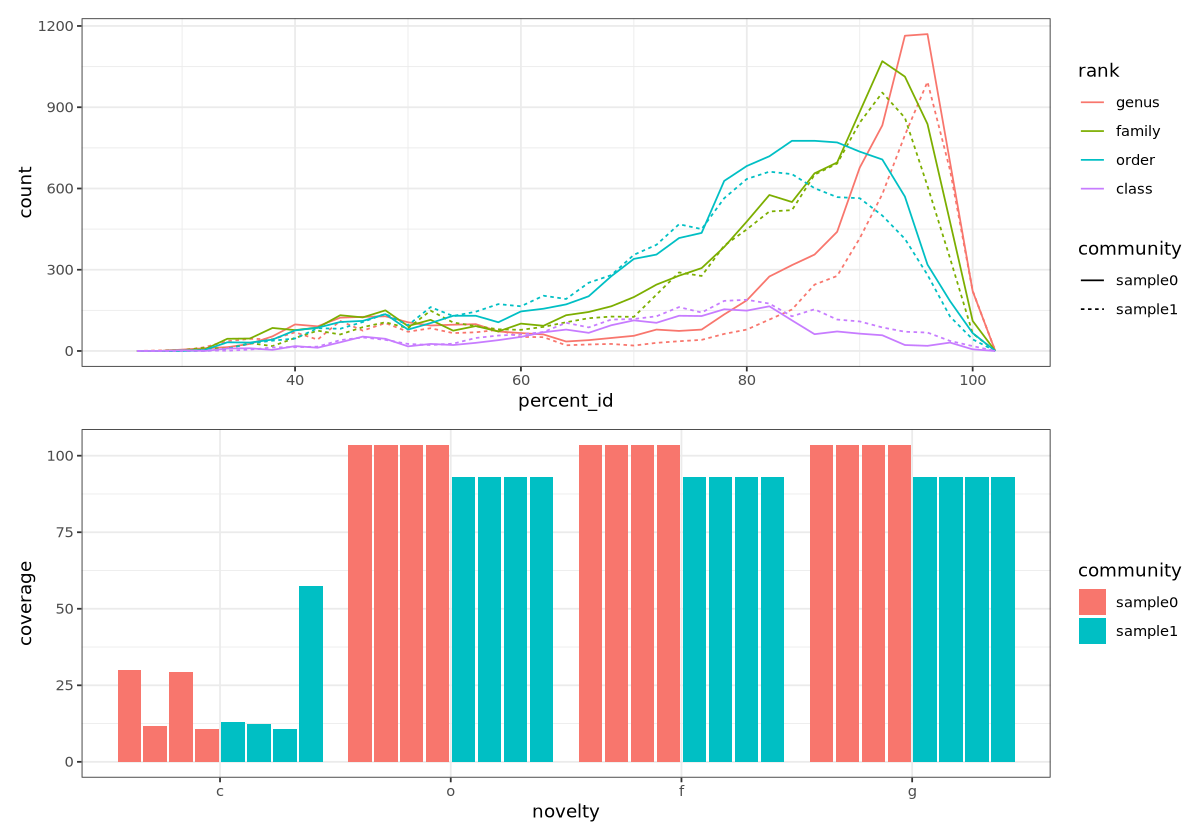

In [8]:
pid_p / n_p

In [9]:
pid_p_mrk <- ggplot(d2, aes(percent_id, colour = factor(marker), linetype = community)) +
  geom_freqpoly(binwidth = 2) +
  facet_wrap(vars(rank))

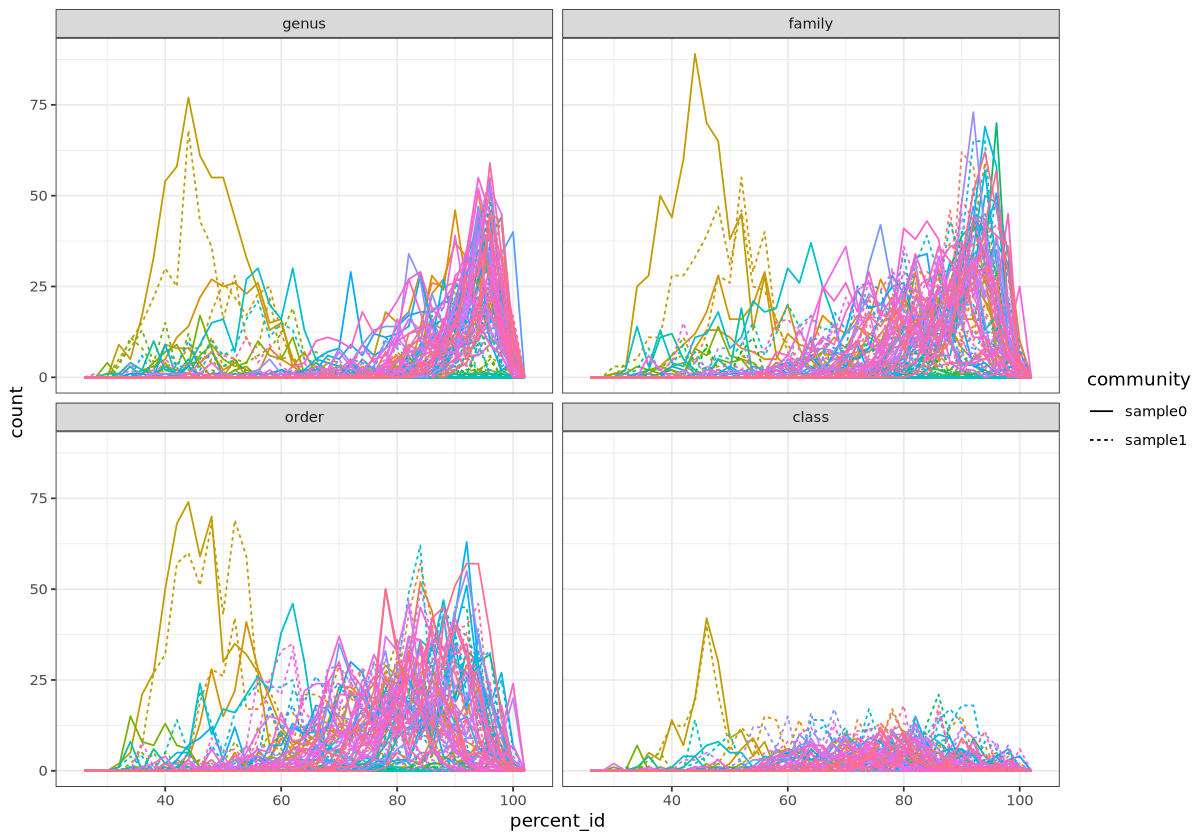

In [10]:
pid_p_mrk +
  scale_colour_discrete(guide = "none")

In [18]:
meds <- d2[, .(median = median(percent_id), mode = modeest::mlv(percent_id, method = "meanshift", bw = 2)),
           by = .(community, rank, marker = factor(marker))]
setorder(meds, rank, median)
meds2 <- melt(meds, id.vars = c("community", "rank", "marker"), measure.vars = c("median", "mode"))

Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal”
Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal”
Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal”
Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal”
Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal”
Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal v

Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal”
Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal”
Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal”
Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal”
Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal”
Warning message:
“encountered a tie, and the difference between minimal and 
                   maximal v

[1] "S3.33.ribosomal_S4e"  "S3.35.RNA_SBDS"       "S3.23.KOW_elon_Spt5" 
 [4] "S3.18.EIF_2_alpha"    "S3.19.eIF_5A"         "S3.26.ribosomal_L19e"
 [7] "S3.37.uS4_arch"       "S3.22.gatD_arch"      "S3.29.ribosomal_L32e"
[10] "S3.27.ribosomal_L21e" "S3.16.SRP_SPB"        "S3.17.dph5"          
[13] "S3.31.ribosomal_S24e" "S3.28.ribosomal_L31e"

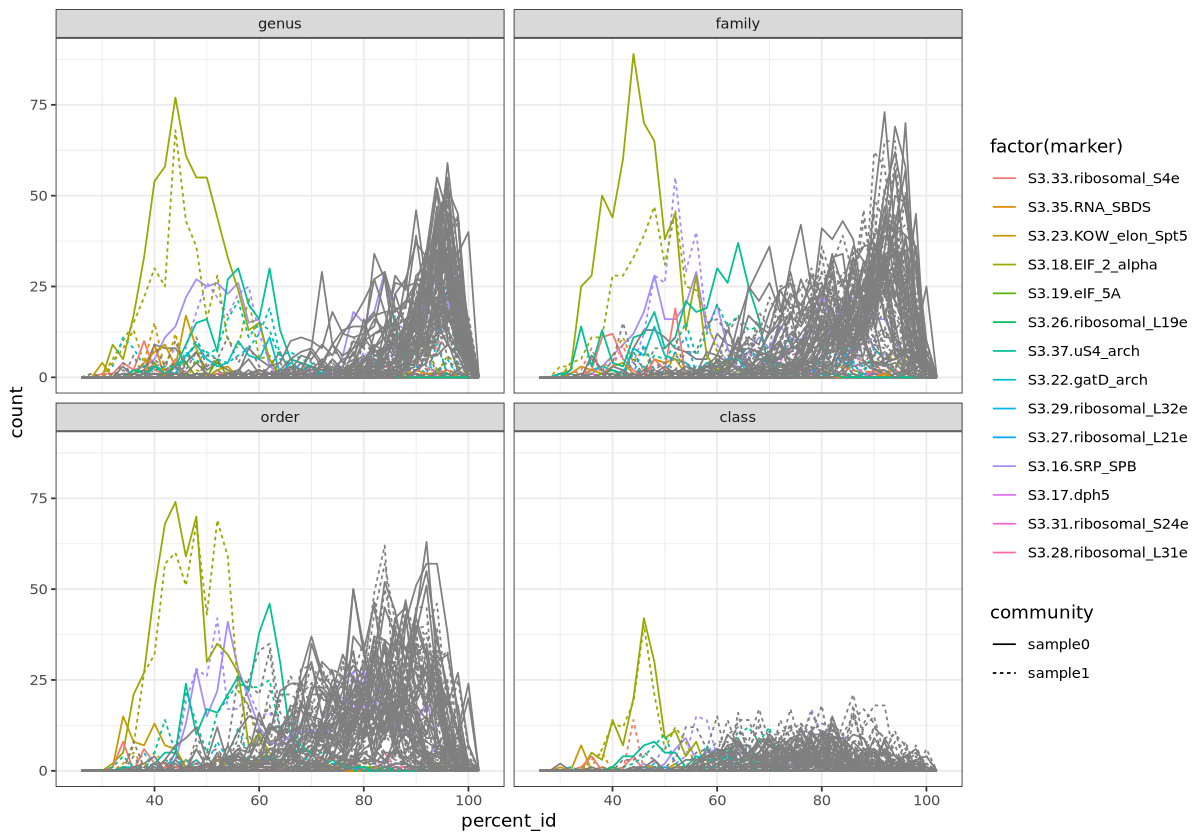

In [12]:
low_mrk <- as.character(unique(meds[median < 60, ]$marker))
low_mrk
pid_p_mrk + scale_colour_discrete(limits = low_mrk)

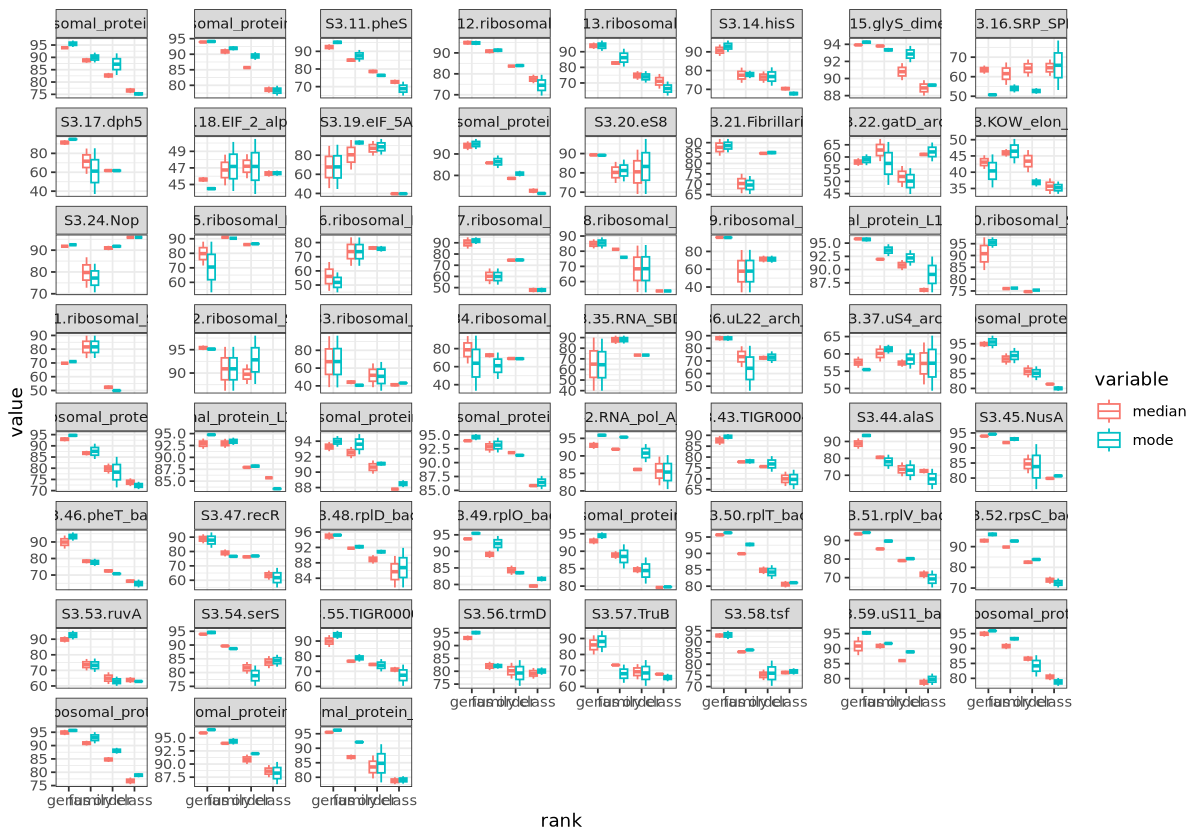

In [36]:
ggplot(meds2, aes(rank, value, colour = variable)) +
    geom_boxplot() +
    facet_wrap(vars(marker), scales = "free_y")

In [30]:
sum_p_mrk <- ggplot(meds2, aes(value, colour = marker, linetype = variable)) +
    geom_freqpoly(binwidth = 5) +
    facet_wrap(vars(rank))

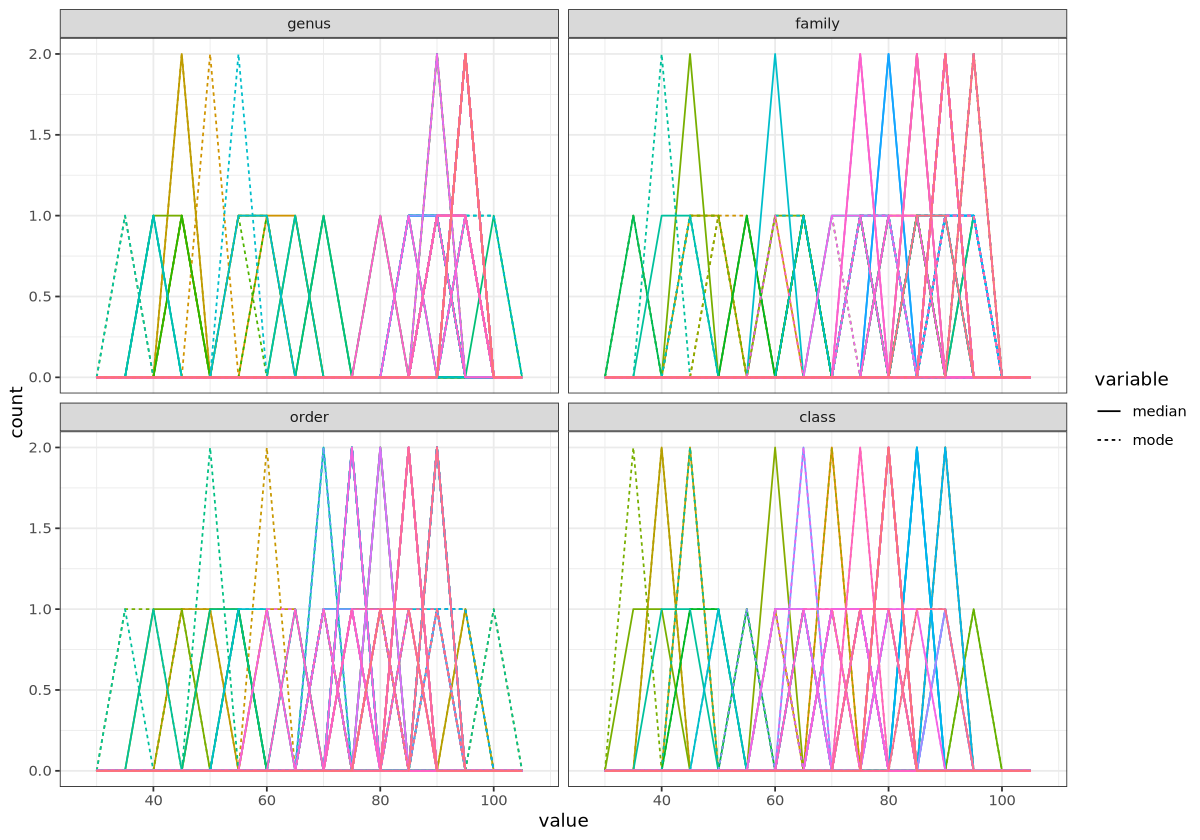

In [31]:
sum_p_mrk + guides(colour = "none")

### Check relationship of percent_id to coverage

In [14]:
npid <- d2[n, on = c("community", "rank", "rep")]

In [15]:
npid[1:5,]

community,rank,rep,otu,percent_id,marker,coverage,novelty,i.coverage
<fct>,<fct>,<int>,<int>,<dbl>,<chr>,<dbl>,<fct>,<dbl>
sample0,genus,0,1,98.0,S3.1.ribosomal_protein_L2_rplB,1.648352,g,103.5041
sample0,genus,0,9,93.9,S3.1.ribosomal_protein_L2_rplB,1.648352,g,103.5041
sample0,genus,0,10,92.0,S3.1.ribosomal_protein_L2_rplB,1.648352,g,103.5041
sample0,genus,0,11,91.8,S3.1.ribosomal_protein_L2_rplB,1.648352,g,103.5041
sample0,genus,0,12,93.9,S3.1.ribosomal_protein_L2_rplB,1.648352,g,103.5041


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_segment()`).”


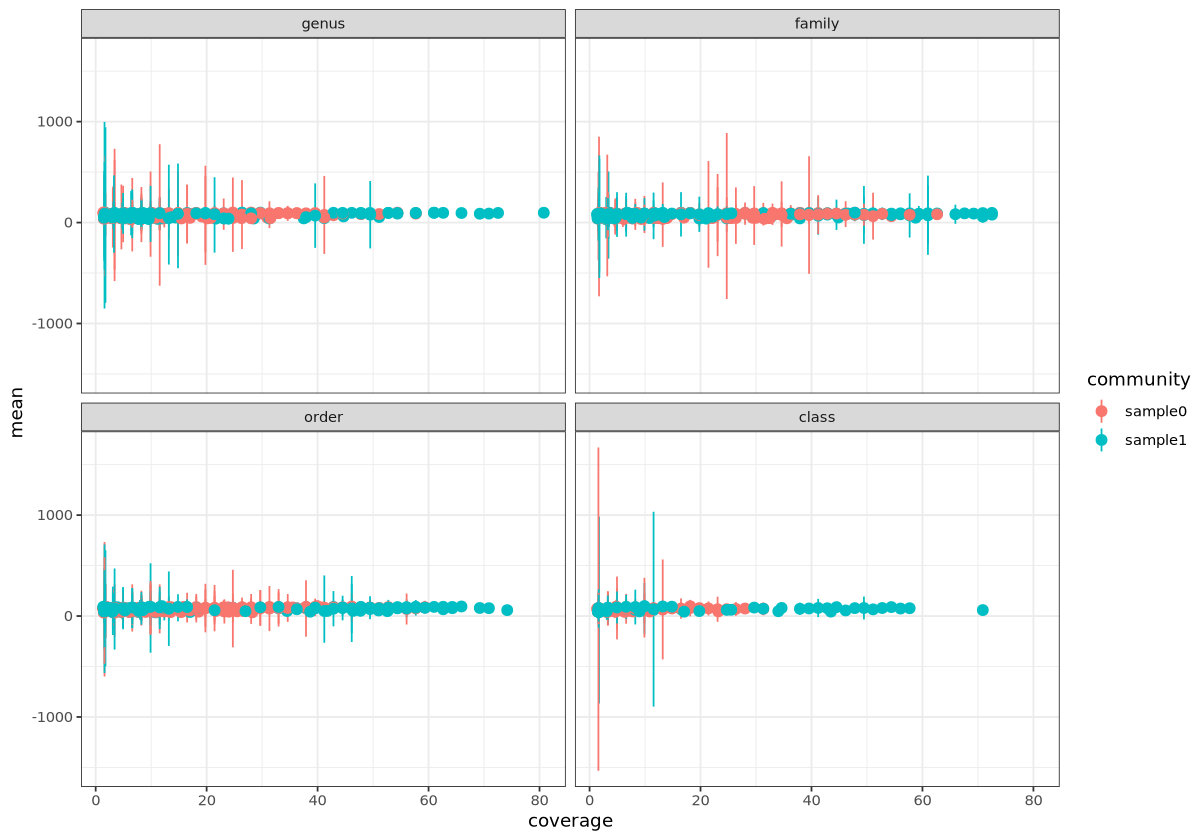

In [16]:
ggplot(
    npid[, .(mean = mean(percent_id), var = var(percent_id)), by = .(community, coverage, rep, rank)],
    aes(coverage,  mean, ymin = mean - var, ymax = mean + var, colour = community)
) +
    geom_pointrange() +
    facet_wrap(vars(rank))